In [58]:
from matplotlib.pyplot import plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix 


In [59]:
df=pd.read_csv(r"D:\Internship-Project\Dataset\Work From Home Employee Burnout Dataset\work_from_home_burnout_dataset.csv")
df.head()


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


In [61]:
# Load burnout dataset
burnout_df = pd.read_csv(r'D:\Internship-Project\Dataset\Work From Home Employee Burnout Dataset\work_from_home_burnout_dataset.csv')

print("Burnout Dataset Shape:", burnout_df.shape)
print("\nFirst 5 rows:")
print(burnout_df.head())

print("\nDataset Info:")
burnout_df.info()

print("\nBurnout Distribution:")
print(burnout_df['burnout_risk'].value_counts())

print("\nStatistical Summary:")
print(burnout_df.describe())

Burnout Dataset Shape: (1800, 11)

First 5 rows:
   user_id day_type  work_hours  screen_time_hours  meetings_count  \
0        1  Weekday        9.59              11.86               4   
1        1  Weekend        7.38              10.33               4   
2        1  Weekend        6.31               8.92               1   
3        1  Weekday        8.34              10.70               4   
4        1  Weekend        6.97               9.83               1   

   breaks_taken  after_hours_work  sleep_hours  task_completion_rate  \
0             2                 0         7.55                  91.2   
1             1                 0         6.69                  82.0   
2             2                 0         8.87                  80.6   
3             1                 1         8.13                  70.0   
4             2                 0         5.85                  67.1   

   burnout_score burnout_risk  
0          19.17          Low  
1          29.70          Low  
2

In [62]:
# Identify numeric and categorical columns for burnout dataset
burnout_numeric_cols = burnout_df.select_dtypes(include=[np.number]).columns.tolist()
burnout_categorical_cols = burnout_df.select_dtypes(include=['object']).columns.tolist()

if 'Burnout' in burnout_numeric_cols:
    burnout_numeric_cols.remove('Burnout')
if 'Burnout' in burnout_categorical_cols:
    burnout_categorical_cols.remove('Burnout')

print("Numeric columns:", burnout_numeric_cols)
print("Categorical columns:", burnout_categorical_cols)



Numeric columns: ['user_id', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'burnout_score']
Categorical columns: ['day_type', 'burnout_risk']


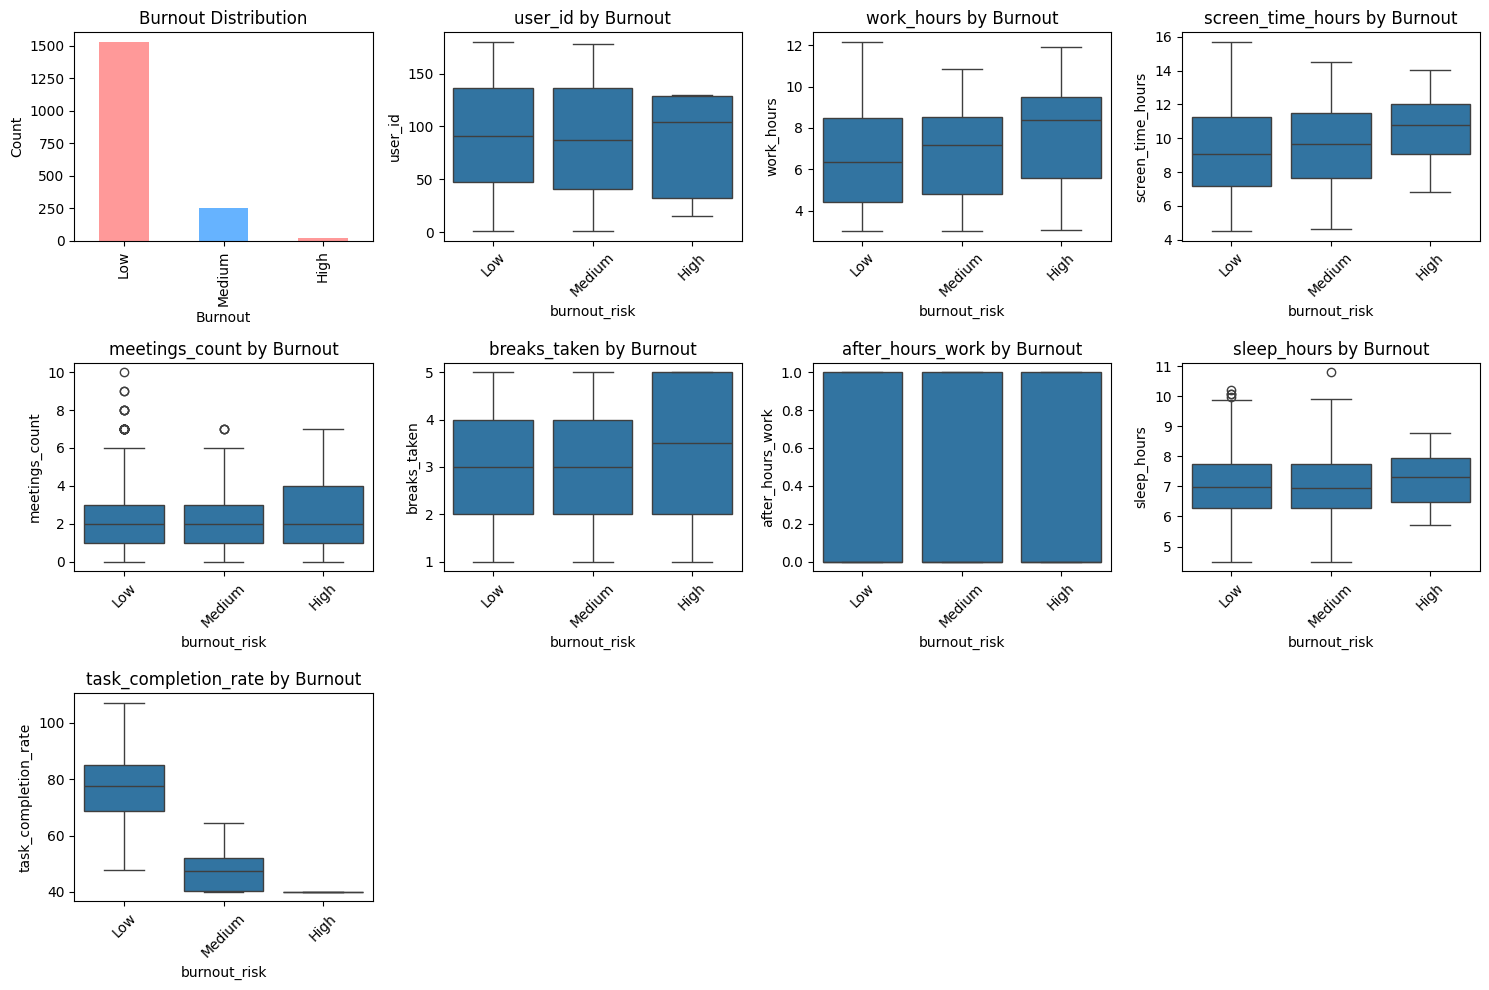

In [63]:
# Visualize burnout distribution
plt.figure(figsize=(15, 10))

# Burnout distribution
plt.subplot(3, 4, 1)
burnout_df['burnout_risk'].value_counts().plot(kind='bar', color=['#ff9999', '#66b3ff'])
plt.title('Burnout Distribution')
plt.xlabel('Burnout')
plt.ylabel('Count')

# Plot numeric features
for i, col in enumerate(burnout_numeric_cols[:8], 2):
    if i <= 9:
        plt.subplot(3, 4, i)
        if col in burnout_df.columns:
            sns.boxplot(data=burnout_df, x='burnout_risk', y=col)
            plt.title(f'{col} by Burnout')
            plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [64]:
# Prepare burnout data
# Handle categorical variables if any
burnout_df_processed = burnout_df.copy()

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in burnout_categorical_cols:
    if col in burnout_df_processed.columns:
        le = LabelEncoder()
        burnout_df_processed[col] = le.fit_transform(burnout_df_processed[col])
        label_encoders[col] = le



In [65]:
# Prepare features and target
X_burnout = burnout_df_processed.drop('burnout_risk', axis=1)
y_burnout = burnout_df_processed['burnout_risk']

# Encode target variable if it's categorical
if y_burnout.dtype == 'object':
    le_burnout = LabelEncoder()
    y_burnout_encoded = le_burnout.fit_transform(y_burnout)
    print("Encoded Burnout Classes:")
    for i, class_name in enumerate(le_burnout.classes_):
        print(f"{class_name}: {i}")
else:
    y_burnout_encoded = y_burnout
    le_burnout = None



In [66]:
# Split the data
X_burnout_train, X_burnout_test, y_burnout_train, y_burnout_test = train_test_split(
    X_burnout, y_burnout_encoded, test_size=0.2, random_state=42, stratify=y_burnout_encoded
)

print(f"\nTraining set size: {X_burnout_train.shape[0]}")
print(f"Test set size: {X_burnout_test.shape[0]}")

# Scale features
scaler_burnout = StandardScaler()
X_burnout_train_scaled = scaler_burnout.fit_transform(X_burnout_train)
X_burnout_test_scaled = scaler_burnout.transform(X_burnout_test)


Training set size: 1440
Test set size: 360


In [67]:
# Define models for burnout prediction
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

burnout_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Train and evaluate models
burnout_results = {}

print("Training Burnout Prediction Models...")
print("=" * 50)

for name, model in burnout_models.items():
    # Train model
    model.fit(X_burnout_train_scaled, y_burnout_train)
    
    # Make predictions
    y_pred = model.predict(X_burnout_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_burnout_test, y_pred)
    cv_scores = cross_val_score(model, X_burnout_train_scaled, y_burnout_train, cv=5)
    
    burnout_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"{name}:")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print()

# Find best model
best_burnout_model = max(burnout_results.items(), key=lambda x: x[1]['accuracy'])
print(f"Best Burnout Model: {best_burnout_model[0]} with accuracy {best_burnout_model[1]['accuracy']:.4f}")

Training Burnout Prediction Models...
Random Forest:
  Test Accuracy: 1.0000
  CV Accuracy: 0.9986 (+/- 0.0034)

SVM:
  Test Accuracy: 0.9667
  CV Accuracy: 0.9743 (+/- 0.0168)

Logistic Regression:
  Test Accuracy: 0.9889
  CV Accuracy: 0.9882 (+/- 0.0034)

Decision Tree:
  Test Accuracy: 0.9972
  CV Accuracy: 0.9972 (+/- 0.0028)

KNN:
  Test Accuracy: 0.9444
  CV Accuracy: 0.9535 (+/- 0.0209)

Naive Bayes:
  Test Accuracy: 0.9500
  CV Accuracy: 0.9507 (+/- 0.0315)

Best Burnout Model: Random Forest with accuracy 1.0000


In [68]:
import os
import joblib

In [69]:
save_dir = "Employee_burnout_models"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [70]:
for name, details in burnout_results.items():
    model = details['model']
    
    # Clean file name (remove spaces)
    file_name = name.replace(" ", "_").lower() + ".pkl"
    file_path = os.path.join(save_dir, file_name)
    
    joblib.dump(model, file_path)
    print(f"✅ {name} saved at {file_path}")

✅ Random Forest saved at Employee_burnout_models\random_forest.pkl
✅ SVM saved at Employee_burnout_models\svm.pkl
✅ Logistic Regression saved at Employee_burnout_models\logistic_regression.pkl
✅ Decision Tree saved at Employee_burnout_models\decision_tree.pkl
✅ KNN saved at Employee_burnout_models\knn.pkl
✅ Naive Bayes saved at Employee_burnout_models\naive_bayes.pkl


<Figure size 1200x600 with 0 Axes>

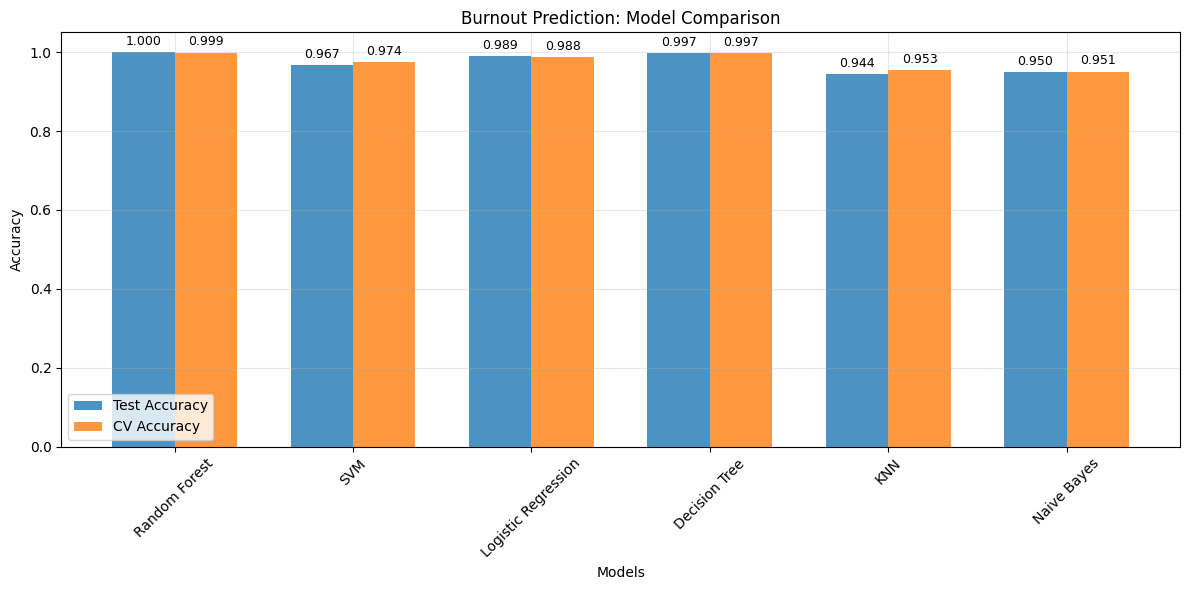

In [71]:
# Visualize burnout model performance
plt.figure(figsize=(12, 6))

model_names = list(burnout_results.keys())
accuracies = [burnout_results[name]['accuracy'] for name in model_names]
cv_means = [burnout_results[name]['cv_mean'] for name in model_names]
cv_stds = [burnout_results[name]['cv_std'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy', alpha=0.8)
bars2 = ax.bar(x + width/2, cv_means, width, label='CV Accuracy', alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Burnout Prediction: Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [74]:
print("\n📊 Model Comparison (Accuracy %):")
print("=" * 50)

for name, result in burnout_results.items():
    acc_percent = result['accuracy'] * 100
    
    # Highlight best model
    if name == best_burnout_model[0]:
        print(f"🏆 {name}: {acc_percent:.2f}%  <-- BEST MODEL")
    else:
        print(f"{name}: {acc_percent:.2f}%")


📊 Model Comparison (Accuracy %):
🏆 Random Forest: 100.00%  <-- BEST MODEL
SVM: 96.67%
Logistic Regression: 98.89%
Decision Tree: 99.72%
KNN: 94.44%
Naive Bayes: 95.00%


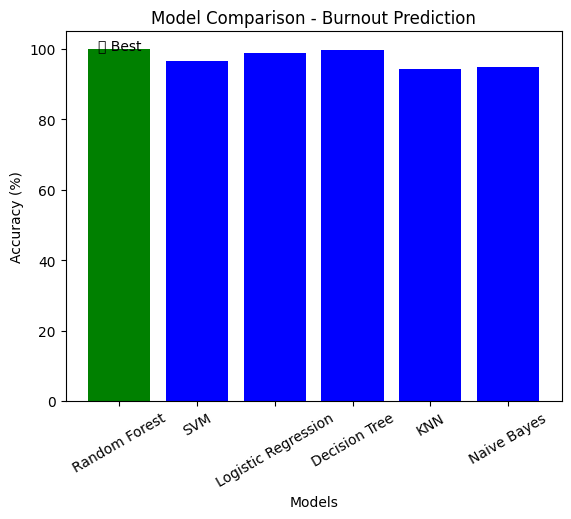

In [75]:
import matplotlib.pyplot as plt

names = list(burnout_results.keys())
accuracies = [result['accuracy'] * 100 for result in burnout_results.values()]

# Create colors list (default + highlight best)
colors = ['blue'] * len(names)
best_index = names.index(best_burnout_model[0])
colors[best_index] = 'green'   # Highlight best model

plt.figure()
plt.bar(names, accuracies, color=colors)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison - Burnout Prediction")

# Add label on best model
plt.text(best_index, accuracies[best_index], "🏆 Best", ha='center')

plt.xticks(rotation=30)
plt.show()

In [79]:
print("\n" + "="*50)
print("🎉 Training & Saving Completed Successfully!")
print(f"🏆 Best Model: {best_burnout_model[0]}")
print("="*50)


🎉 Training & Saving Completed Successfully!
🏆 Best Model: Random Forest
